## Urszula Michalska, Natalia Rogalska


In [1]:
from sklearn.neighbors import NeighborhoodComponentsAnalysis, KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import time

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

c:\Users\halsk\anaconda3\envs\python_proj\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\halsk\anaconda3\envs\python_proj\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\halsk\anaconda3\envs\python_proj\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\halsk\anaconda3\envs\python_proj\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), fo

Elapsed time: 10.723859 seconds


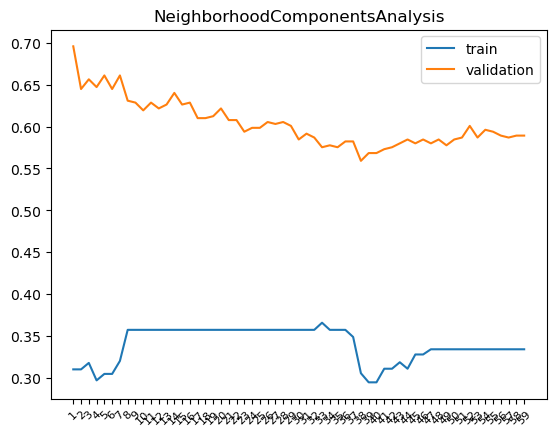

In [3]:


start = time.perf_counter()





nca = NeighborhoodComponentsAnalysis(random_state=12)
nca.fit(X_train, y_train)
X_train_snca = nca.transform(X_train)
X_test_snca = nca.transform(X_test)

train_acc=[]
val_acc=[]
k_values= range(1,60)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_snca, y_train)
    y_pred_val = model.predict(X_test_snca)
    y_pred_train = model.predict(X_train)
    train_acc.append(accuracy_score(y_train, y_pred_train))
    val_acc.append(accuracy_score(y_test, y_pred_val))

end = time.perf_counter()

print(f"Elapsed time: {end - start:.6f} seconds")

plt.figure()
plt.title("NeighborhoodComponentsAnalysis")
plt.plot(k_values, train_acc, label="train")
plt.plot(k_values, val_acc, label="validation")
plt.xticks(k_values, rotation = 45, fontsize = 8)
plt.legend()

c:\Users\halsk\anaconda3\envs\python_proj\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Elapsed time: 0.013070 seconds
Classification Report:
              precision    recall  f1-score   support

         0.0       0.61      0.67      0.64       143
         1.0       0.66      0.79      0.72       144
         2.0       0.57      0.40      0.47       144

    accuracy                           0.62       431
   macro avg       0.61      0.62      0.61       431
weighted avg       0.61      0.62      0.61       431



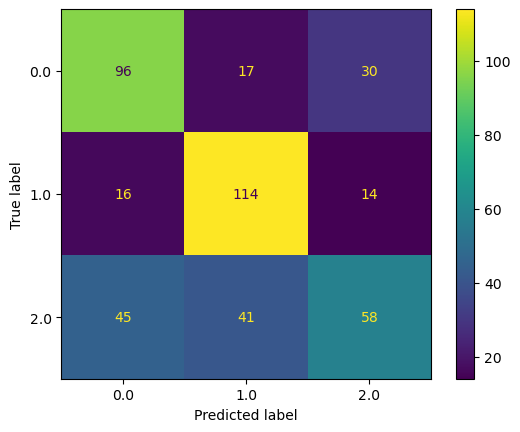

In [4]:
start = time.perf_counter()
model_knn = KNeighborsClassifier(n_neighbors=20)
model_knn.fit(X_train_snca, y_train)
y_pred = model_knn.predict(X_test_snca)

end = time.perf_counter()

print(f"Elapsed time: {end - start:.6f} seconds")

cm = confusion_matrix(y_test, y_pred, labels=model_knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_knn.classes_)
disp.plot()
class_report_knn = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report_knn)
